# 03 — American Airlines Delay Cost Analysis

**Purpose:** Analyze delay-related operational costs for American Airlines (AA) across airports, delay causes, and time dimensions to identify the highest-impact areas for cost reduction.

**Input:**
- `data/flights_clean.parquet` — cleaned flight data from `02_clean.ipynb`

**Business Questions:**
1. Which airports generate the highest delay-related operational costs?
2. Which delay causes drive the most cost?
3. When do delays cost the most — by time of day, day of week, and month?
4. Where should American Airlines focus first to reduce costs?

**Key columns used:**

| Column | Description |
|---|---|
| `OP_UNIQUE_CARRIER` | Airline IATA code — filtered to `AA` |
| `ORIGIN` | Origin airport code — used for airport-level aggregation |
| `DEP_DELAY_COST` | Total estimated delay cost per flight |
| `CARRIER_COST`, `WEATHER_COST`, `NAS_COST`, `SECURITY_COST`, `LATE_AIRCRAFT_COST` | Cost broken down by delay cause |
| `TIME_BLOCK` | Departure time group (Morning / Afternoon / Night) |
| `IS_WEEKEND` | Weekend vs. weekday flag |
| `MONTH_NAME` | Month name for seasonal trend analysis |
| `DEP_DELAY`, `DEP_DEL15` | Raw delay minutes and binary delay flag |

## Imports

In [13]:
# Add imports here
import sys

sys.path.append("..")   # or "." if running from data/ folder
from utils.logger import get_logger
from utils.filters import select_airline 
import pandas as pd
import matplotlib.pyplot as plt
logging = get_logger()                                                                                                                                                                                                   


## Load & Filter to American Airlines

In [14]:
# Load data/flights_clean.parquet
# Filter to AA using filter_airline() or direct filter on OP_UNIQUE_CARRIER
df = pd.read_parquet("data/flights_2024_clean.parquet")
aa_df = select_airline(df, "AA")

In [15]:
aa_df.head()

,YEAR,MONTH,DAY_OF_WEEK,OP_UNIQUE_CARRIER,ORIGIN,ORIGIN_CITY_NAME,DEST,DEST_CITY_NAME,CRS_DEP_TIME,DEP_DELAY,...,DAY,AIRLINE,DEP_DELAY_COST,CARRIER_COST,WEATHER_COST,NAS_COST,SECURITY_COST,LATE_AIRCRAFT_COST,TIME_BLOCK,IS_WEEKEND
2633,2024,1,1,AA,ABQ,"Albuquerque, NM",DFW,"Dallas/Fort Worth, TX",600,-9.0,...,Monday,American Airlines Inc.,0.00,0.00,0.0,0.00,0.0,0.0,Morning,False
2634,2024,1,1,AA,ABQ,"Albuquerque, NM",DFW,"Dallas/Fort Worth, TX",600,0.0,...,Monday,American Airlines Inc.,0.00,0.00,0.0,4231.92,0.0,0.0,Morning,False
2635,2024,1,1,AA,ABQ,"Albuquerque, NM",DFW,"Dallas/Fort Worth, TX",600,108.0,...,Monday,American Airlines Inc.,10882.08,10882.08,0.0,8363.08,0.0,0.0,Morning,False
2636,2024,1,1,AA,ABQ,"Albuquerque, NM",DFW,"Dallas/Fort Worth, TX",606,-3.0,...,Monday,American Airlines Inc.,0.00,0.00,0.0,0.00,0.0,0.0,Morning,False
2637,2024,1,1,AA,ABQ,"Albuquerque, NM",DFW,"Dallas/Fort Worth, TX",820,-9.0,...,Monday,American Airlines Inc.,0.00,0.00,0.0,0.00,0.0,0.0,Morning,False


In [16]:
aa_df.shape

(969629, 29)

In [17]:
aa_df.columns

Index(['YEAR', 'MONTH', 'DAY_OF_WEEK', 'OP_UNIQUE_CARRIER', 'ORIGIN',
       'ORIGIN_CITY_NAME', 'DEST', 'DEST_CITY_NAME', 'CRS_DEP_TIME',
       'DEP_DELAY', 'DEP_DEL15', 'DISTANCE', 'CARRIER_DELAY', 'WEATHER_DELAY',
       'NAS_DELAY', 'SECURITY_DELAY', 'LATE_AIRCRAFT_DELAY', 'source_file',
       'MONTH_NAME', 'DAY', 'AIRLINE', 'DEP_DELAY_COST', 'CARRIER_COST',
       'WEATHER_COST', 'NAS_COST', 'SECURITY_COST', 'LATE_AIRCRAFT_COST',
       'TIME_BLOCK', 'IS_WEEKEND'],
      dtype='object')

## Q1: Which airports generate the highest delay costs?

Metrics: total delay cost, cost share (%), average delay per flight, delay rate, number of flights

In [18]:
total_cost = aa_df['DEP_DELAY_COST'].sum()                                                                                                              
print(f"${total_cost:,.0f}")                                                                                                                            
print(f"Total Delay Cost is ${total_cost/1e9:.2f}B")

$2,288,226,954
Total Delay Cost is $2.29B


In [19]:
# Group by ORIGIN: sum DEP_DELAY_COST, mean DEP_DELAY, mean DEP_DEL15, count flights
airport_stats = aa_df.groupby('ORIGIN').agg({
    'DEP_DELAY_COST':'sum',
    'DEP_DELAY':'mean',
    'DEP_DEL15':'mean',
    'ORIGIN':'count'
}).rename(columns={'ORIGIN':'NUM_FLIGHTS'}).reset_index()
# Compute COST_SHARE = airport cost / total cost
airport_stats['COST_SHARE'] = airport_stats['DEP_DELAY_COST']/airport_stats['DEP_DELAY_COST'].sum()
# Show top 10
airport_stats = airport_stats.sort_values(by='DEP_DELAY_COST', ascending=False)
top10 = airport_stats.head(10)
print(top10)

   ORIGIN  DEP_DELAY_COST  DEP_DELAY  DEP_DEL15  NUM_FLIGHTS  COST_SHARE
32    DFW    4.384109e+08  24.942213   0.339917       163081    0.191594
25    CLT    2.962250e+08  21.662838   0.300881       124860    0.129456
76    MIA    1.513092e+08  23.619986   0.311232        58940    0.066125
89    ORD    1.241934e+08  21.583932   0.266816        51470    0.054275
93    PHL    9.484327e+07  18.022525   0.243746        44928    0.041448
94    PHX    9.209343e+07  13.660688   0.202833        54917    0.040247
64    LAX    6.034819e+07  17.065903   0.199232        30211    0.026373
30    DCA    5.515643e+07  16.813906   0.216130        27067    0.024104
71    MCO    3.914183e+07  18.878370   0.235404        17693    0.017106
6     AUS    3.676954e+07  22.999854   0.205755        13657    0.016069


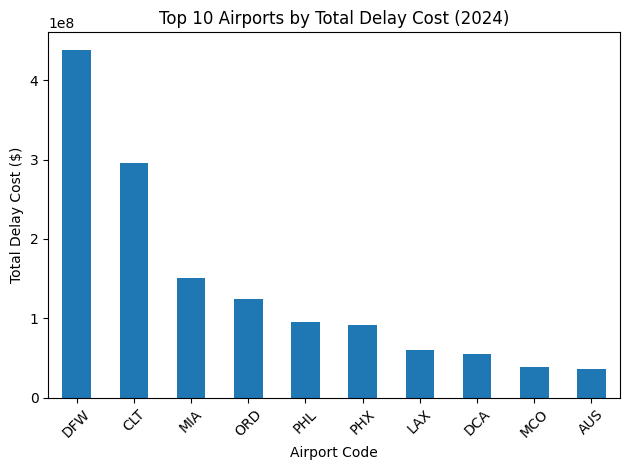

In [20]:
top10.plot(
    x='ORIGIN',
    y='DEP_DELAY_COST',
    kind='bar',
    legend=False
)

plt.title('Top 10 Airports by Total Delay Cost (2024)')
plt.ylabel('Total Delay Cost ($)')
plt.xlabel('Airport Code')
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

## Q2: Which delay causes drive the most cost?

Causes: Carrier, Weather, NAS, Security, Late Aircraft

In [21]:
# Sum each cause cost column
# Compute CostShare per cause
cause_cost = pd.DataFrame({
    'Cause': ['Carrier', 'Weather', 'NAS', 'Security', 'Late Aircraft'],
    'Total_Cost': [
        aa_df['CARRIER_COST'].sum(),
        aa_df['WEATHER_COST'].sum(),
        aa_df['NAS_COST'].sum(),
        aa_df['SECURITY_COST'].sum(),
        aa_df['LATE_AIRCRAFT_COST'].sum()
    ]
})

cause_cost['Cost_Share'] = cause_cost['Total_Cost']/(cause_cost['Total_Cost'].sum())
cause_cost = cause_cost.sort_values(by='Total_Cost', ascending=False)
cause_cost

,Cause,Total_Cost,Cost_Share
4,Late Aircraft,1.056887e+09,0.484659
0,Carrier,7.175706e+08,0.329058
2,NAS,2.838014e+08,0.130144
1,Weather,1.183211e+08,0.054259
3,Security,4.099622e+06,0.001880


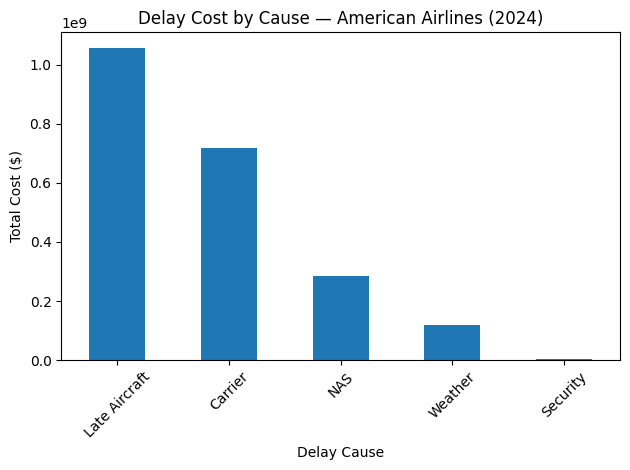

In [22]:
cause_cost.plot(
    x='Cause',
    y='Total_Cost',
    kind='bar',
    legend=False
)
plt.title('Delay Cost by Cause — American Airlines (2024)')
plt.ylabel('Total Cost ($)')
plt.xlabel('Delay Cause')
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

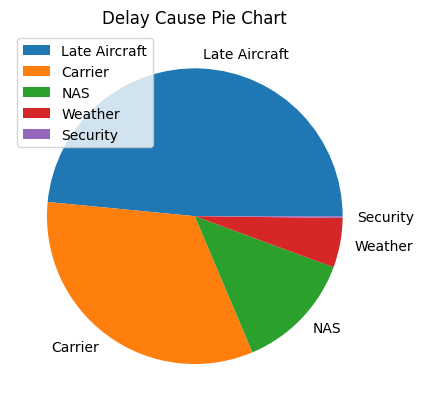

In [23]:
# pie chart 
plt.pie(cause_cost['Cost_Share'], labels=cause_cost['Cause'])
plt.title('Delay Cause Pie Chart')
plt.legend()
plt.show()

## Q3: When do delays cost the most?

In [24]:
# Group by TIME_BLOCK: total delay cost
time_cost = aa_df.groupby('TIME_BLOCK')['DEP_DELAY_COST'].sum().reset_index()
time_cost = time_cost.sort_values(by='DEP_DELAY_COST', ascending=False)
time_cost

,TIME_BLOCK,DEP_DELAY_COST
0,Afternoon,8.574717e+08
2,Night,7.692456e+08
1,Morning,6.615097e+08


In [25]:
# Group by IS_WEEKEND: total delay cost
weekend_cost = aa_df.groupby('IS_WEEKEND')['DEP_DELAY_COST'].sum()
weekend_cost.reset_index()

,IS_WEEKEND,DEP_DELAY_COST
0,False,1.634771e+09
1,True,6.534562e+08


In [26]:
# Group by MONTH_NAME: total delay cost, sorted descending
month_cost = aa_df.groupby('MONTH_NAME')['DEP_DELAY_COST'].sum().reset_index()
month_cost = month_cost.sort_values(by='DEP_DELAY_COST', ascending=False)
month_cost

,MONTH_NAME,DEP_DELAY_COST
5,July,3.331415e+08
8,May,2.948828e+08
6,June,2.640091e+08
1,August,2.432314e+08
7,March,2.001036e+08
4,January,1.957079e+08
0,April,1.662609e+08
2,December,1.603766e+08
11,September,1.182144e+08
10,October,1.090346e+08


In [27]:
# Cross-tab: TIME_BLOCK x IS_WEEKEND — total delay cost
print(aa_df.groupby(['TIME_BLOCK','IS_WEEKEND'])['DEP_DELAY_COST'].sum())

TIME_BLOCK  IS_WEEKEND
Afternoon   False         6.153190e+08
            True          2.421528e+08
Morning     False         4.748696e+08
            True          1.866401e+08
Night       False         5.445822e+08
            True          2.246634e+08
Name: DEP_DELAY_COST, dtype: float64


## Q4: Where should AA focus first?

Drill into the single highest-cost segment: DFW + Night + Late Aircraft delay

In [28]:
# Filter: ORIGIN == 'DFW', TIME_BLOCK == 'Night'
# Summarize delay cause costs for this segment
# Compare to overall AA baseline
dfw = aa_df[
    (aa_df['ORIGIN'] == 'DFW') &
    (aa_df['TIME_BLOCK'] == 'Night')
]

causes = dfw[[
    'CARRIER_COST',
    'WEATHER_COST',
    'NAS_COST',
    'SECURITY_COST',
    'LATE_AIRCRAFT_COST'
]].sum()
print(causes.sort_values(ascending=False))

LATE_AIRCRAFT_COST    87138457.12
CARRIER_COST          58213283.92
NAS_COST              12953101.04
WEATHER_COST           9893523.64
SECURITY_COST           170385.16
dtype: float64


## Conclusion

### Key Findings

**Airport Cost Distribution**
DFW is the single largest cost driver, accounting for **19.2% ($438M)** of AA's total 2024
delay cost across 163,081 flights — the highest volume, average delay (24.9 min), and delay
rate (34%) of any hub. CLT ranks second at **13.0% ($296M)**, followed by MIA at **6.6% ($151M)**.
Together, these three airports represent nearly **39% of total delay cost**.

**Delay Causes**
The majority of delay cost is driven by **controllable, internal factors**:
- Late Aircraft: **48.5%** (~$1.06B)
- Carrier: **32.9%** (~$718M)
- Combined internal: **~81%** of total cost

Weather and NAS — largely uncontrollable — account for only ~19% combined.

**Temporal Patterns**
- **Afternoon departures** generate the highest total delay cost ($857M), followed by Night ($769M) and Morning ($661M) — though afternoon volume is also highest.
- **Weekdays** account for ~71% of total cost ($1.63B vs $653M on weekends), proportional to higher weekday flight volume.
- **Summer months dominate**: July ($333M), May ($295M), and June ($264M) are the top 3 most costly months — likely driven by higher demand and cascading delays.

**Strategic Focus: DFW Nighttime Operations**
Drilling into the highest-cost segment — DFW night departures — reveals late aircraft delay
alone costs **$87M**, with carrier delay adding another **$58M**. This single segment
represents a significant, addressable opportunity.

### Recommendation
American Airlines should prioritize **turnaround efficiency at DFW**, particularly for evening
banks of flights. Since ~81% of delay cost stems from internal causes (late aircraft + carrier),
operational improvements — better ground crew scheduling, proactive maintenance, and buffer time
on high-risk routes — could materially reduce costs without dependency on weather or ATC.